Loading data from disk...
  Scanning 1000 files for Conventional...
  -> Loaded 207 valid tiles for Conventional
  Scanning 1000 files for Conservational...
  -> Loaded 4 valid tiles for Conservational
  Scanning 1000 files for Rotational...
  -> Loaded 6 valid tiles for Rotational

--- Applying SMOTE ---
Original shape: (217, 64, 64, 10)
Original distribution: {'Conventional': np.int64(207), 'Conservational': np.int64(4), 'Rotational': np.int64(6)}
New shape after SMOTE: (621, 64, 64, 10)
New distribution: {'Conventional': np.int64(207), 'Conservational': np.int64(207), 'Rotational': np.int64(207)}

Starting Training...
Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.7278 - loss: 0.7191
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.8851 - loss: 0.2674
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9476 - loss: 0.1659
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9677 - loss: 0.0848
Epoch 5/25
16/16 ━━━━━━━━━━

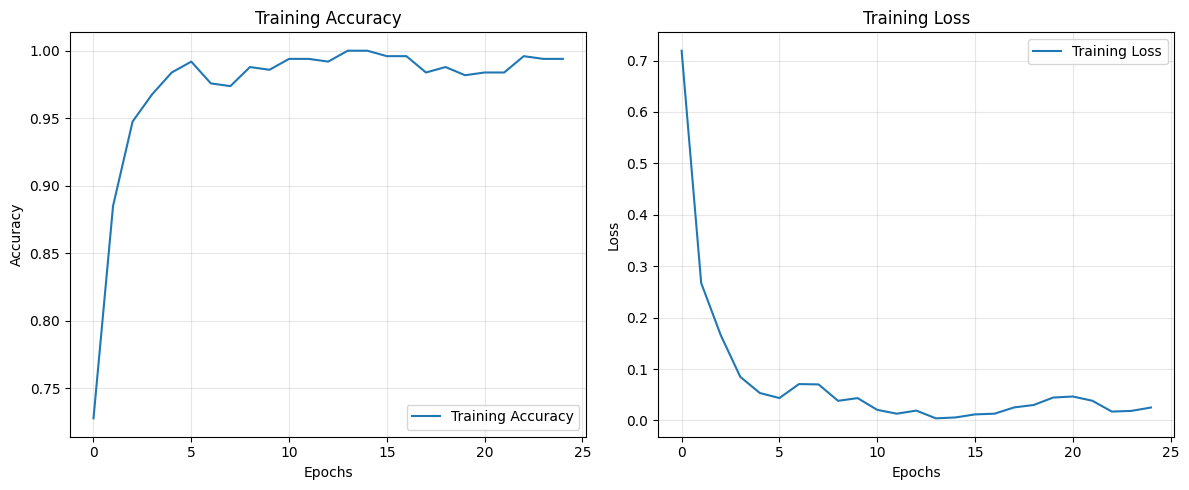

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step

Classification Report:
                precision    recall  f1-score   support

  Conventional       0.00      0.00      0.00        41
Conservational       1.00      0.10      0.17        42
    Rotational       0.35      1.00      0.52        42

      accuracy                           0.37       125
     macro avg       0.45      0.37      0.23       125
  weighted avg       0.45      0.37      0.23       125



c:\Users\Wilson\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wilson\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Wilson\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense, GlobalAveragePooling2D
from keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = "data"
CLASSES = ["Conventional", "Conservational", "Rotational"]  # All 3 classes
IMG_HEIGHT, IMG_WIDTH, CHANNELS = 64, 64, 10

# ==========================================
# 2. DATA LOADING
# ==========================================
def load_data(data_dir, classes):
    images = []
    labels = []
    label_map = {name: i for i, name in enumerate(classes)}
    NODATA_VALUE = -32768.0 

    print("Loading data from disk...")
    for c in classes:
        path = os.path.join(data_dir, c)
        if not os.path.exists(path):
            print(f"  [WARNING] Folder not found: {path}")
            continue
            
        files = [f for f in os.listdir(path) if f.endswith('.npy')]
        print(f"  Scanning {len(files)} files for {c}...")
        
        kept = 0
        for f in files:
            try:
                # Load .npy file
                img_array = np.load(os.path.join(path, f)).astype('float32')
                
                # Basic validation: Check if image is mostly empty/NoData
                if np.mean(img_array == NODATA_VALUE) > 0.9: 
                    continue
                    
                # Preprocessing: Clip and Normalize
                img_array[img_array == NODATA_VALUE] = 0.0
                img_array = np.clip(img_array, 0, 10000)
                img_array = img_array / 10000.0
                
                # Resize if necessary
                if img_array.shape != (IMG_HEIGHT, IMG_WIDTH, CHANNELS):
                    img_array = cv2.resize(img_array, (IMG_WIDTH, IMG_HEIGHT))
                
                images.append(img_array)
                labels.append(label_map[c])
                kept += 1
            except Exception as e:
                continue
        print(f"  -> Loaded {kept} valid tiles for {c}")

    return np.array(images), np.array(labels)

# ==========================================
# 3. CNN MODEL
# ==========================================
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    # Conv Block 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Conv Block 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)
    
    # Conv Block 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)
    
    # Conv Block 4 (Target for Grad-CAM)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name="last_conv")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs, name="Tillage_CNN")

# ==========================================
# 4. PERFORMANCE GRAPHS FUNCTION
# ==========================================
def plot_training_history(history):
    acc = history.history['accuracy']
    loss = history.history['loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.legend(loc='upper right')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Step 1: Load data
    X, y = load_data(DATA_DIR, CLASSES)
    
    if len(X) == 0:
        raise ValueError("No data loaded! Please check if data exists in the 'data' directory.")
    
    # Step 2: Apply SMOTE Balancing
    print("\n--- Applying SMOTE ---")
    print(f"Original shape: {X.shape}")
    unique, counts = np.unique(y, return_counts=True)
    print(f"Original distribution: {dict(zip([CLASSES[i] for i in unique], counts))}")
    
    # Flatten for SMOTE
    n_samples = X.shape[0]
    X_flat = X.reshape(n_samples, -1)
    
    # Apply SMOTE (k_neighbors=1 for robustness with small classes)
    k = 1 if min(counts) < 2 else 2
    smote = SMOTE(k_neighbors=k, random_state=42)
    X_res, y_res = smote.fit_resample(X_flat, y)
    
    # Reshape back to 4D Image format for CNN
    X_res = X_res.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)
    
    print(f"New shape after SMOTE: {X_res.shape}")
    unique_res, counts_res = np.unique(y_res, return_counts=True)
    print(f"New distribution: {dict(zip([CLASSES[i] for i in unique_res], counts_res))}")
    
    # Step 3: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
    )
    
    # Step 4: Build and compile model
    model = build_model((IMG_HEIGHT, IMG_WIDTH, CHANNELS), len(CLASSES))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Step 5: Train model
    print("\nStarting Training...")
    history = model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=32,
        verbose=1
    )
    
    # Step 6: Plot training history
    plot_training_history(history)
    
    # Step 7: Evaluation
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=CLASSES))

Training on balanced data shape: (957, 64, 64, 10)
Testing on data shape: (240, 64, 64, 10)
Class distribution in Train: (array([0, 1, 2]), array([319, 319, 319]))
Class Weights (Safety check): {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,635 (1.62 MB)

 Trainable params: 424,675 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.7565 - loss: 0.6427 - val_accuracy: 0.3333 - val_loss: 2.1848
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9425 - loss: 0.1737 - val_accuracy: 0.3333 - val_loss: 3.9351
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9572 - loss: 0.1175 - val_accuracy: 0.3333 - val_loss: 5.3080
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.9812 - loss: 0.0572 - val_accuracy: 0.3333 - val_loss: 5.0200
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.9781 - loss: 0.0622 - val_accuracy: 0.3333 - val_loss: 5.3615
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9801 - loss: 0.0609 - val_accuracy: 0.3333 - val_loss: 7.2180
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9948 - loss: 0.0283 - val_accuracy: 0.3333 - val_loss: 8.2021
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.9927 - loss: 0.0302 - val_accuracy: 0.

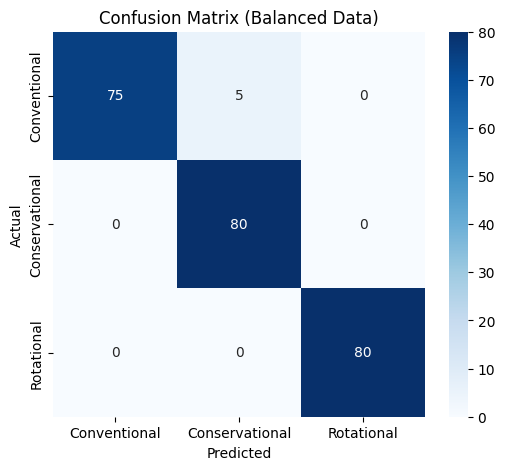

                precision    recall  f1-score   support

  Conventional       1.00      0.94      0.97        80
Conservational       0.94      1.00      0.97        80
    Rotational       1.00      1.00      1.00        80

      accuracy                           0.98       240
     macro avg       0.98      0.98      0.98       240
  weighted avg       0.98      0.98      0.98       240



In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense, GlobalAveragePooling2D
from keras.models import Model
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

print(f"Training on balanced data shape: {X_train.shape}")
print(f"Testing on data shape: {X_test.shape}")
print(f"Class distribution in Train: {np.unique(y_train, return_counts=True)}")
print(f"Class Weights (Safety check): {class_weights_dict}")

# Define CNN Model (output layer changed to 2 classes)
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 10)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),
    
    # Block 4
    Conv2D(256, (3, 3), activation='relu', padding='same', name='last_conv'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Classification Head
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Changed from 3 to 2 classes
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=CLASSES))

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.9927 - loss: 0.0337 - val_accuracy: 0.9167 - val_loss: 0.5533
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.9969 - loss: 0.0089 - val_accuracy: 0.9042 - val_loss: 0.2731
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.9948 - loss: 0.0132 - val_accuracy: 0.8125 - val_loss: 1.2703
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9927 - loss: 0.0251 - val_accuracy: 0.9958 - val_loss: 0.0091
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9917 - val_loss: 0.0141
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9990 - loss: 0.0054 - val_accuracy: 0.9917 - val_loss: 0.0248
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9979 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 8.5094e-04
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy

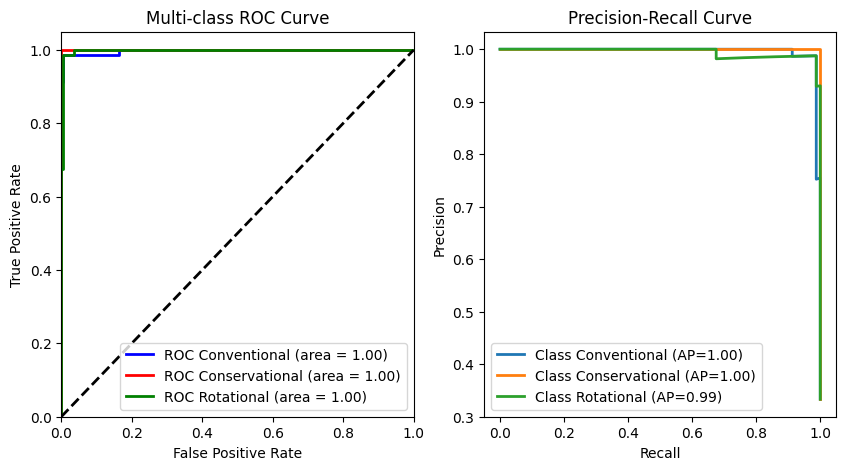

NameError: name 'make_gradcam_heatmap' is not defined

<Figure size 1500x500 with 0 Axes>

In [7]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ==========================================
# 1. TRAINING (With Focal Loss for Imbalance)
# ==========================================
# Standard cross-entropy often ignores hard-to-classify examples (minority class).
# Focal Loss forces the model to focus on the hard examples.

def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))-K.sum((1-alpha) * K.pow( pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# Re-compile model with the new data
# Note: If you don't have a custom loss function defined, stick to 'sparse_categorical_crossentropy'
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=15, 
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict
)

# ==========================================
# 2. GENERATE PREDICTIONS
# ==========================================
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================================
# 3. ADVANCED ML CHARTS
# ==========================================

# --- CHART A: ROC Curve (Receiver Operating Characteristic) ---
# 

# Useful to see if the model is better than random guessing (diagonal line)
y_test_bin = label_binarize(y_test, classes=[0, 1])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC for each class
for i in range(len(CLASSES)):
    # Create binary labels for current class vs rest
    y_true_binary = (y_test == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(y_true_binary, y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(len(CLASSES)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC {0} (area = {1:0.2f})'.format(CLASSES[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")

# --- CHART B: Precision-Recall Curve ---
#  - Crucial for imbalanced datasets
# It highlights how well the model finds the minority class without false positives
plt.subplot(1, 2, 2)
precision = dict()
recall = dict()
average_precision = dict()

for i in range(len(CLASSES)):
    y_true_binary = (y_test == i).astype(int)
    precision[i], recall[i], _ = precision_recall_curve(y_true_binary, y_pred_prob[:, i])
    average_precision[i] = average_precision_score(y_true_binary, y_pred_prob[:, i])
    plt.plot(recall[i], precision[i], lw=2, label=f'Class {CLASSES[i]} (AP={average_precision[i]:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.show()

# ==========================================
# 4. MULTIPLE GRAD-CAM IMAGES
# ==========================================
# We will generate 3 different examples, specifically looking for different classes

def get_gradcam_enc(img_tensor):
    return make_gradcam_heatmap(model, img_tensor, "last_conv") # Ensure 'last_conv' matches your layer name

# Pick 3 random indices from test set
target_indices = np.random.choice(np.arange(len(X_test)), 3, replace=False)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(target_indices):
    img_tensor = np.expand_dims(X_test[idx], axis=0)
    
    # Generate Heatmap
    heatmap = get_gradcam_enc(img_tensor)
    
    # Process RGB for display
    rgb_img = X_test[idx][:, :, [2, 1, 0]]
    rgb_img = np.clip(rgb_img, 0, 1)
    
    # Resize & Colorize
    heatmap_resized = cv2.resize(heatmap, (rgb_img.shape[1], rgb_img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    # Superimpose
    superimposed = 0.5 * rgb_img + 0.5 * heatmap_colored
    
    # Plot
    true_label = CLASSES[y_test[idx]]
    pred_label = CLASSES[y_pred[idx]]
    confidence = np.max(y_pred_prob[idx])
    
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(superimposed, 0, 1))
    plt.title(f"True: {true_label}\\nPred: {pred_label} ({confidence:.2f})")
    plt.axis('off')

plt.suptitle("Grad-CAM: What the model is looking at", fontsize=16)
plt.show()

--- Conventional ---
Shape: (64, 64, 10)
Min Value: -32768.0 | Max Value: 12981.765625 | Mean: -23830.82
Valid Pixels: 40960 / 40960 (100.0%)
--- Conservational ---
Shape: (64, 64, 10)
Min Value: -32768.0 | Max Value: -32768.0 | Mean: -32768.00
Valid Pixels: 40960 / 40960 (100.0%)
--- Rotational ---
Shape: (64, 64, 10)
Min Value: -32768.0 | Max Value: -32768.0 | Mean: -32768.00
Valid Pixels: 40960 / 40960 (100.0%)


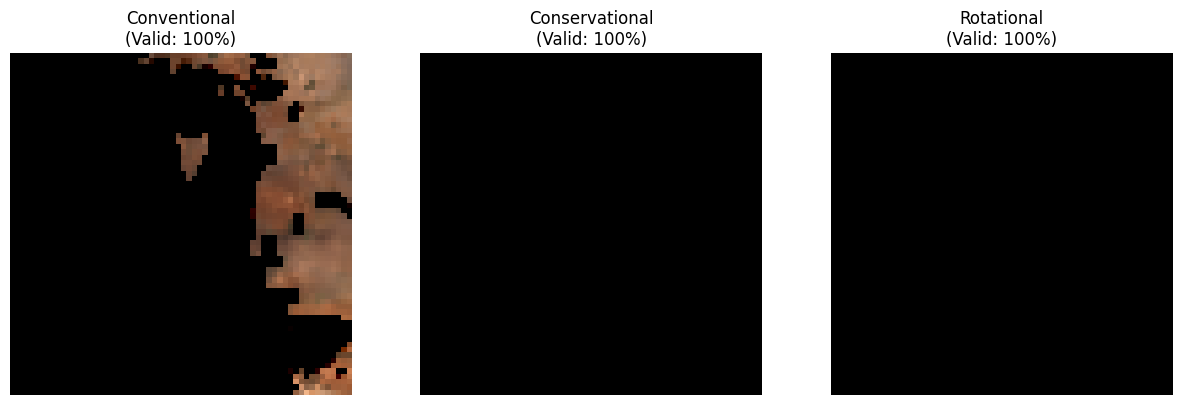

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# CONFIG
DATA_DIR = "data"
CLASSES = ["Conventional", "Conservational", "Rotational"]

def inspect_data():
    plt.figure(figsize=(15, 5))
    
    for i, c in enumerate(CLASSES):
        path = os.path.join(DATA_DIR, c)
        files = [f for f in os.listdir(path) if f.endswith('.npy')]
        
        if not files:
            print(f"No files found for {c}!")
            continue
            
        # Load a random file
        file_path = os.path.join(path, np.random.choice(files))
        data = np.load(file_path)
        
        # Check Stats
        print(f"--- {c} ---")
        print(f"Shape: {data.shape}")
        print(f"Min Value: {data.min()} | Max Value: {data.max()} | Mean: {data.mean():.2f}")
        
        # Count non-zero pixels (Check for "Empty" images)
        non_zeros = np.count_nonzero(data)
        total_pixels = data.size
        print(f"Valid Pixels: {non_zeros} / {total_pixels} ({non_zeros/total_pixels*100:.1f}%)")
        
        # Plot RGB (B4, B3, B2 are indices 2, 1, 0)
        # We assume data is roughly 0-3000 (Int16). 
        # Divide by 3000 to visualize.
        rgb = data[:, :, [2, 1, 0]].astype('float32') / 3000.0
        rgb = np.clip(rgb, 0, 1) # Force valid range
        
        plt.subplot(1, 3, i+1)
        plt.imshow(rgb)
        plt.title(f"{c}\n(Valid: {non_zeros/total_pixels*100:.0f}%)")
        plt.axis('off')
    
    plt.show()

inspect_data()

In [2]:
import numpy as np
import os

# Pick a class folder that exists
target_dir = os.path.join("data", "Conventional") 
files = [f for f in os.listdir(target_dir) if f.endswith('.npy')]

if files:
    # Load one file
    img = np.load(os.path.join(target_dir, files[0]))
    
    print("--- INSPECTING ONE TILE ---")
    print(f"Shape: {img.shape}")
    print(f"Contains NaNs? {np.isnan(img).any()}")
    print(f"Min Value: {np.nanmin(img)}")
    print(f"Max Value: {np.nanmax(img)}")
    print(f"Unique Values (first 20): {np.unique(img)[:20]}")
else:
    print("No files found.")

--- INSPECTING ONE TILE ---
Shape: (64, 64, 10)
Contains NaNs? False
Min Value: -32768.0
Max Value: -32768.0
Unique Values (first 20): [-32768.]
